# HR Analytics: Employee Performance, Attrition & Workforce Analysis

In [1]:
import pandas as pd
import seaborn as sns
import numpy as ny
import matplotlib.pyplot as plt

In [2]:
employees = pd.read_csv(r"C:\Users\subho\Downloads\hr_relational_dataset\employees.csv")

departments = pd.read_csv(r"C:\Users\subho\Downloads\hr_relational_dataset\departments.csv")

job_roles = pd.read_csv(r"C:\Users\subho\Downloads\hr_relational_dataset\job_roles.csv")

locations = pd.read_csv(r"C:\Users\subho\Downloads\hr_relational_dataset\locations.csv")

salary = pd.read_csv(r"C:\Users\subho\Downloads\hr_relational_dataset\salary.csv")

performance = pd.read_csv(r"C:\Users\subho\Downloads\hr_relational_dataset\performance.csv")

attendance = pd.read_csv(r"C:\Users\subho\Downloads\hr_relational_dataset\attendance.csv")

training = pd.read_csv(r"C:\Users\subho\Downloads\hr_relational_dataset\training.csv")

In [3]:
employees.head()

,Employee_ID,First_Name,Last_Name,Gender,Age,Marital_Status,Department_ID,Role_ID,Location_ID,Employment_Type,Work_Mode,Education_Level,Years_of_Experience,Hire_Date,Manager_ID,Attrition_Status
0,EMP00001,Samaira,Solanki,Male,23,Married,D002,R001,L006,Full-Time,Remote,Master's,6,2022-08-03,NaN,Resigned
1,EMP00002,Taimur,Sane,Male,23,Single,D002,R015,L003,Full-Time,Remote,Bachelor's,35,2017-03-25,NaN,Active
2,EMP00003,Mannat,Cheema,Female,39,Single,D001,R015,L001,Full-Time,Onsite,Diploma,21,2018-02-12,EMP00001,Active
3,EMP00004,Trisha,Rao,Female,28,Single,D005,R014,L003,Part-Time,Remote,MBA,22,2021-10-08,EMP00003,Active
4,EMP00005,Bhavin,Magar,Female,56,Single,D002,R003,L004,Part-Time,Remote,MBA,23,2021-06-22,EMP00002,Active


In [4]:
employees.isnull().sum()

Employee_ID            0
First_Name             0
Last_Name              0
Gender                 0
Age                    0
Marital_Status         0
Department_ID          0
Role_ID                0
Location_ID            0
Employment_Type        0
Work_Mode              0
Education_Level        0
Years_of_Experience    0
Hire_Date              0
Manager_ID             9
Attrition_Status       0
dtype: int64

In [5]:
employees['Hire_Date'] = pd.to_datetime(
    employees['Hire_Date']
)

In [6]:
departments.head()

,Department_ID,Department_Name
0,D001,Human Resources
1,D002,Finance
2,D003,Sales
3,D004,Marketing
4,D005,IT


In [7]:
job_roles.head()

,Role_ID,Job_Role,Salary_Band_Min,Salary_Band_Max
0,R001,HR Executive,350000,650000
1,R002,HR Manager,700000,1500000
2,R003,Financial Analyst,500000,1200000
3,R004,Accountant,350000,700000
4,R005,Sales Executive,300000,900000


In [8]:
locations.head()

,Location_ID,City,State,Country
0,L001,Mumbai,Maharashtra,India
1,L002,Delhi,Delhi,India
2,L003,Bangalore,Karnataka,India
3,L004,Kolkata,West Bengal,India
4,L005,Chennai,Tamil Nadu,India


In [9]:
salary.head()

,Salary_Record_ID,Employee_ID,Base_Salary_INR,Bonus_Percentage,Annual_Hike_Percentage,Last_Promotion_Year
0,SAL718274,EMP00001,617562,20.10,12.43,2022
1,SAL541597,EMP00002,538532,17.83,5.34,2022
2,SAL528519,EMP00003,415880,21.64,12.48,2018
3,SAL103827,EMP00004,1008200,19.67,14.94,2025
4,SAL975876,EMP00005,923915,23.32,3.04,2022


In [10]:
performance.head()

,Performance_ID,Employee_ID,Performance_Rating,Projects_Handled,Training_Hours,Employee_Satisfaction_Score,Work_Life_Balance
0,PERF399116,EMP00001,4,12,47,2.4,3
1,PERF989655,EMP00002,3,12,63,4.4,1
2,PERF889826,EMP00003,4,8,54,3.4,5
3,PERF598408,EMP00004,3,5,24,2.1,4
4,PERF541713,EMP00005,3,2,44,3.8,3


In [11]:
attendance.head()

,Attendance_ID,Employee_ID,Month,Attendance_Percentage,Leaves_Taken,Overtime_Hours,Monthly_Working_Hours
0,ATD435362,EMP00001,Nov,99.98,23,19,179
1,ATD954554,EMP00002,Sep,86.94,5,6,193
2,ATD399524,EMP00003,Sep,99.60,23,16,224
3,ATD242406,EMP00004,Aug,92.43,18,29,171
4,ATD157180,EMP00005,Mar,89.58,1,27,212


In [12]:
training.head()

,Training_ID,Employee_ID,Training_Program,Training_Date,Training_Hours,Training_Status
0,TRN235699,EMP00001,Communication Skills,2024-12-14,40,Completed
1,TRN671026,EMP00002,Cybersecurity Awareness,2022-11-26,18,Completed
2,TRN449082,EMP00003,Leadership Training,2025-04-15,33,Completed
3,TRN848836,EMP00004,Python for Analytics,2023-11-19,16,Completed
4,TRN733514,EMP00005,Advanced Excel,2024-02-19,9,In Progress


In [13]:
training['Training_Date'] = pd.to_datetime(
    training['Training_Date']
)

In [15]:
hr_df = employees.merge(
    departments,
    on='Department_ID',
    how='left'
).merge(
    job_roles,
    on='Role_ID',
    how='left'
).merge(
    locations,
    on='Location_ID',
    how='left'
).merge(
    salary,
    on='Employee_ID',
    how='left'
).merge(
    performance,
    on='Employee_ID',
    how='left'
).merge(
    attendance,
    on='Employee_ID',
    how='left'
).merge(
    training,
    on='Employee_ID',
    how='left'
)

In [16]:
hr_df.shape

hr_df.info()

hr_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Employee_ID                  2000 non-null   object        
 1   First_Name                   2000 non-null   object        
 2   Last_Name                    2000 non-null   object        
 3   Gender                       2000 non-null   object        
 4   Age                          2000 non-null   int64         
 5   Marital_Status               2000 non-null   object        
 6   Department_ID                2000 non-null   object        
 7   Role_ID                      2000 non-null   object        
 8   Location_ID                  2000 non-null   object        
 9   Employment_Type              2000 non-null   object        
 10  Work_Mode                    2000 non-null   object        
 11  Education_Level              2000 non-null 

,Employee_ID,First_Name,Last_Name,Gender,Age,Marital_Status,Department_ID,Role_ID,Location_ID,Employment_Type,...,Month,Attendance_Percentage,Leaves_Taken,Overtime_Hours,Monthly_Working_Hours,Training_ID,Training_Program,Training_Date,Training_Hours_y,Training_Status
0,EMP00001,Samaira,Solanki,Male,23,Married,D002,R001,L006,Full-Time,...,Nov,99.98,23,19,179,TRN235699,Communication Skills,2024-12-14,40,Completed
1,EMP00002,Taimur,Sane,Male,23,Single,D002,R015,L003,Full-Time,...,Sep,86.94,5,6,193,TRN671026,Cybersecurity Awareness,2022-11-26,18,Completed
2,EMP00003,Mannat,Cheema,Female,39,Single,D001,R015,L001,Full-Time,...,Sep,99.60,23,16,224,TRN449082,Leadership Training,2025-04-15,33,Completed
3,EMP00004,Trisha,Rao,Female,28,Single,D005,R014,L003,Part-Time,...,Aug,92.43,18,29,171,TRN848836,Python for Analytics,2023-11-19,16,Completed
4,EMP00005,Bhavin,Magar,Female,56,Single,D002,R003,L004,Part-Time,...,Mar,89.58,1,27,212,TRN733514,Advanced Excel,2024-02-19,9,In Progress


In [17]:
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Employee_ID                  2000 non-null   object        
 1   First_Name                   2000 non-null   object        
 2   Last_Name                    2000 non-null   object        
 3   Gender                       2000 non-null   object        
 4   Age                          2000 non-null   int64         
 5   Marital_Status               2000 non-null   object        
 6   Department_ID                2000 non-null   object        
 7   Role_ID                      2000 non-null   object        
 8   Location_ID                  2000 non-null   object        
 9   Employment_Type              2000 non-null   object        
 10  Work_Mode                    2000 non-null   object        
 11  Education_Level              2000 non-null 

# Key Performance Indicators (KPIs)

kpis = {

    'Total Employees':
    employees['Employee_ID'].nunique(),

    'Active Employees':
    employees[
        employees['Attrition_Status'] == 'Active'
    ]['Employee_ID'].nunique(),

    'Attrition Rate %':
    round(
        (
            employees['Attrition_Status']
            .value_counts(normalize=True)['Resigned']
        ) * 100,
        2
    ),

    'Average Salary':
    round(
        salary['Base_Salary_INR'].mean(),
        2
    ),

    'Average Performance Rating':
    round(
        performance['Performance_Rating'].mean(),
        2
    )

}

kpis

# Employee Analysis

<Axes: xlabel='Gender'>

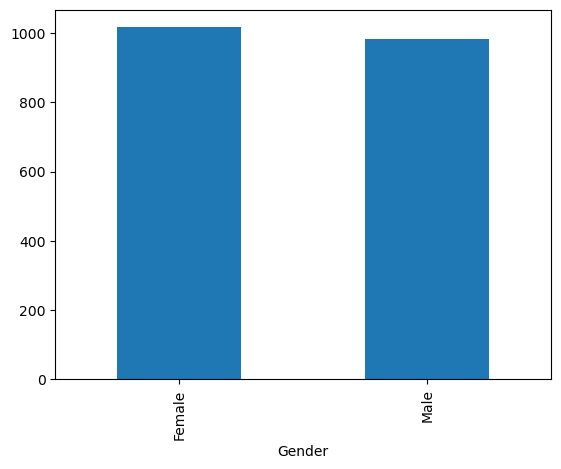

In [25]:
# Gender Distribution
employees['Gender'].value_counts().plot(
    kind='bar'
)

<Axes: xlabel='Department_Name'>

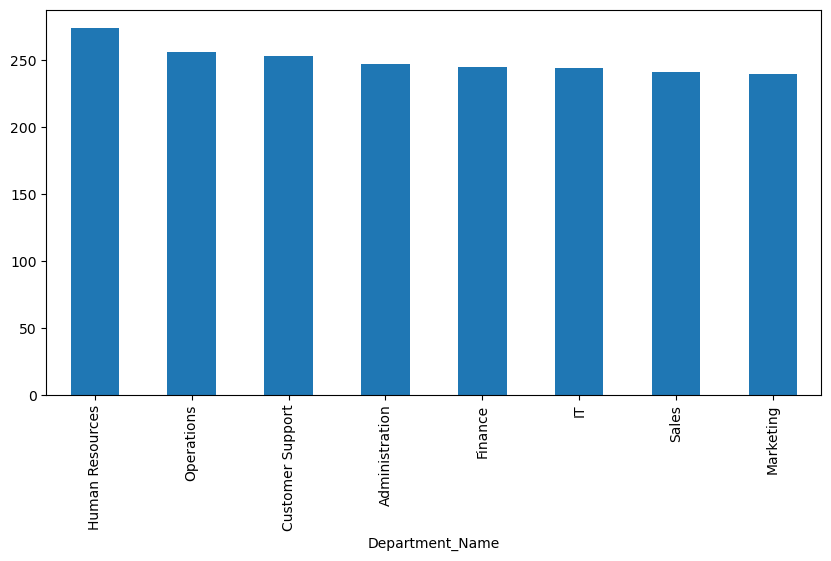

In [27]:
emp_dept_count = hr_df[
    'Department_Name'
].value_counts()

emp_dept_count
emp_dept_count.plot(
    kind='bar',
    figsize=(10,5)
)

In [28]:
employees['Employment_Type'].value_counts()

Employment_Type
Full-Time    695
Contract     665
Part-Time    640
Name: count, dtype: int64

In [29]:
employees['Work_Mode'].value_counts()

Work_Mode
Onsite    675
Remote    669
Hybrid    656
Name: count, dtype: int64

In [30]:
employees['Education_Level'].value_counts()

Education_Level
Bachelor's    526
Diploma       508
Master's      491
MBA           475
Name: count, dtype: int64

In [31]:
employees['Age'].describe()

count    2000.000000
mean       39.911500
std        10.532195
min        22.000000
25%        31.000000
50%        40.000000
75%        49.000000
max        58.000000
Name: Age, dtype: float64

<Axes: >

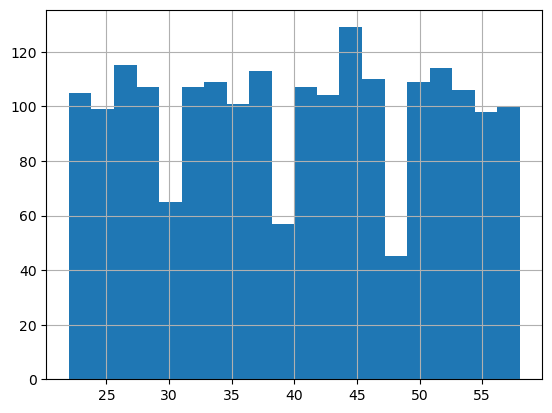

In [32]:
employees['Age'].hist(
    bins=20
)

In [33]:
employees[
    'Years_of_Experience'
].describe()

count    2000.000000
mean       17.714000
std        10.477982
min         0.000000
25%         9.000000
50%        18.000000
75%        27.000000
max        35.000000
Name: Years_of_Experience, dtype: float64

In [34]:
hr_df['City'].value_counts()

City
Kolkata      275
Guwahati     274
Hyderabad    266
Bangalore    261
Pune         257
Chennai      237
Delhi        231
Mumbai       199
Name: count, dtype: int64

## Employee Analysis Insights

- The workforce has a balanced gender distribution, with female employees slightly higher than male employees.

- Employee count is evenly distributed across departments, indicating balanced workforce allocation throughout the organization.

- Human Resources has the highest number of employees, while Marketing and Sales have slightly lower employee counts.

- Full-Time employees represent the largest employment category, followed closely by Contract and Part-Time employees, showing a flexible workforce structure.

- Onsite work mode is slightly more common compared to Remote and Hybrid modes, though all three work arrangements are well balanced.

- Bachelor’s degree holders form the largest educational group, followed by Diploma, Master’s, and MBA holders, indicating educational diversity among employees.

- Employee age distribution is fairly spread across different age groups, suggesting a balanced mix of young and experienced professionals.

- The average employee experience is approximately 18 years, with experience levels ranging from 0 to 35 years.

- The organization contains a healthy mix of entry-level, mid-level, and highly experienced employees.

- Kolkata has the highest employee count among all cities, while Mumbai has the lowest employee count.

- Workforce distribution across cities remains relatively balanced without heavy concentration in a single location.

- Overall, the organization demonstrates strong workforce diversity across gender, education, experience, department, work mode, and geographic location.

# Salary & Compensation Analysis

In [35]:
salary['Base_Salary_INR'].mean()

np.float64(927552.497)

In [38]:
salary['Base_Salary_INR'].max()

2482541

In [37]:
salary['Base_Salary_INR'].min()

250831

Text(0.5, 1.0, 'Salary Distribution')

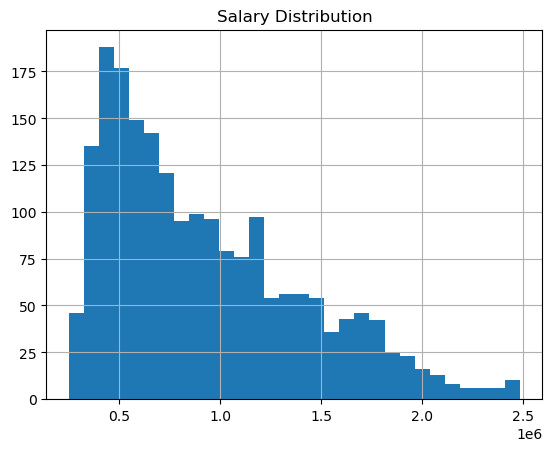

In [40]:
salary['Base_Salary_INR'].hist(
    bins=30
)
plt.title('Salary Distribution')

<Axes: xlabel='Department_Name'>

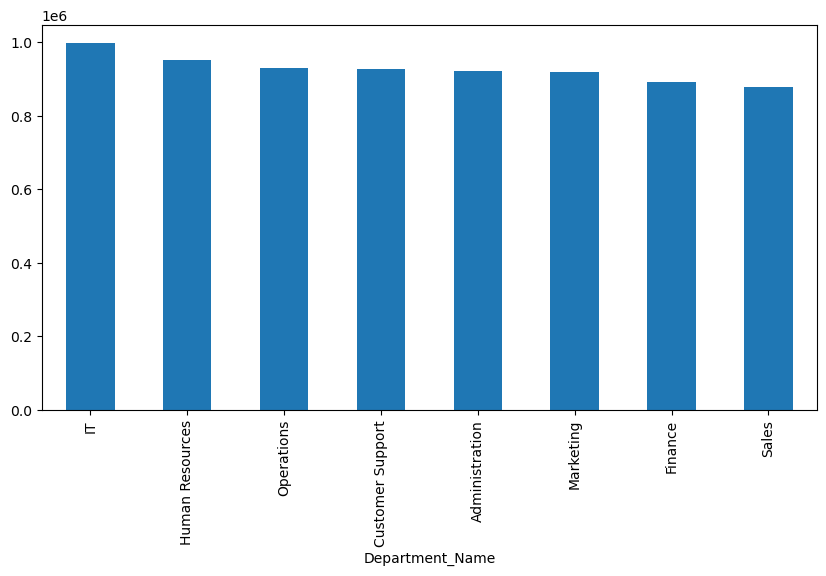

In [42]:
dept_salary = hr_df.groupby(
    'Department_Name'
)['Base_Salary_INR'].mean().sort_values(
    ascending=False
)

dept_salary

dept_salary.plot(
    kind='bar',
    figsize=(10,5)
)

In [43]:
role_salary = hr_df.groupby('Job_Role')['Base_Salary_INR'].mean().sort_values(ascending=False)

role_salary

Job_Role
Data Engineer                 1.673228e+06
Sales Manager                 1.425605e+06
Software Engineer             1.395705e+06
Marketing Manager             1.340805e+06
Operations Manager            1.270029e+06
HR Manager                    1.098410e+06
Data Analyst                  8.771152e+05
Financial Analyst             8.472261e+05
Marketing Analyst             6.521340e+05
Sales Executive               6.001572e+05
Operations Executive          5.889016e+05
Accountant                    5.165715e+05
HR Executive                  4.962495e+05
IT Support                    4.664560e+05
Customer Support Executive    3.959820e+05
Name: Base_Salary_INR, dtype: float64

<Axes: xlabel='Years_of_Experience', ylabel='Base_Salary_INR'>

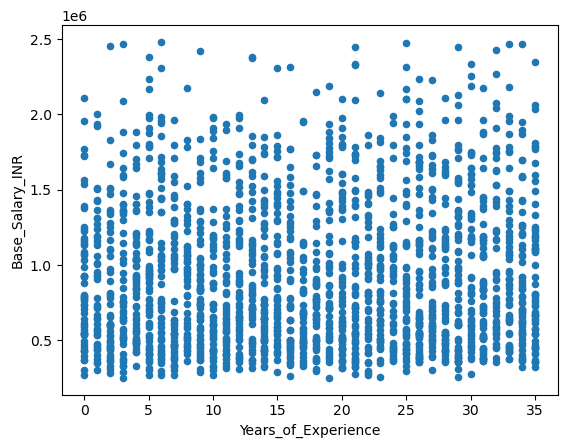

In [44]:
hr_df.plot.scatter(
    x='Years_of_Experience',
    y='Base_Salary_INR'
)

In [45]:
salary['Bonus_Percentage'].describe()

count    2000.000000
mean       15.160230
std         5.713994
min         5.000000
25%        10.447500
50%        15.065000
75%        20.170000
max        25.000000
Name: Bonus_Percentage, dtype: float64

In [46]:
hr_df.groupby( 'Gender')['Base_Salary_INR'].mean()

Gender
Female    939976.509843
Male      914724.451220
Name: Base_Salary_INR, dtype: float64

In [47]:
hr_df[
    [
        'First_Name',
        'Department_Name',
        'Job_Role',
        'Base_Salary_INR'
    ]
].sort_values(
    by='Base_Salary_INR',
    ascending=False
).head(10)

,First_Name,Department_Name,Job_Role,Base_Salary_INR
1243,Zaina,Marketing,Data Engineer,2482541
733,Ayesha,Operations,Data Engineer,2471217
155,Sara,Sales,Data Engineer,2470922
1019,Kavya,Finance,Data Engineer,2469707
1327,Lakshit,Administration,Data Engineer,2465745
1184,Sumer,Human Resources,Data Engineer,2452087
1349,Rania,IT,Data Engineer,2449663
885,Armaan,Administration,Data Engineer,2449412
510,Nehmat,Administration,Data Engineer,2428694
980,Nakul,IT,Data Engineer,2419762


## Salary Analysis Insights

- The average bonus percentage across employees is approximately 15%, with bonus values ranging from 5% to 25%.

- Female employees have a slightly higher average base salary compared to male employees.

- Salary distribution is positively skewed, where most employees fall within the mid-salary range while a smaller number of employees receive significantly higher salaries.

- Base salaries generally increase with years of experience, although some salary variation exists across employees with similar experience levels.

- IT department employees receive the highest average salaries among all departments.

- Sales and Finance departments have comparatively lower average salaries than other departments.

- Data Engineer is the highest-paying job role in the organization.

- Managerial and technical roles such as Sales Manager, Software Engineer, and Marketing Manager also receive relatively high average salaries.

- Customer Support Executive and IT Support roles have the lowest average salary levels.

- The top 10 highest-paid employees are primarily concentrated in technical roles, especially Data Engineer positions.

- Salary differences across departments and job roles indicate role-specific compensation structures within the organization.

- Overall compensation patterns suggest that technical expertise, managerial responsibilities, and specialized roles are rewarded with higher salaries.

# Employee Performance Analysis

In [50]:
performance[
    'Performance_Rating'
].mean()

np.float64(3.4685)

In [51]:
performance[
    'Performance_Rating'
].value_counts()

Performance_Rating
4    714
3    693
5    303
2    197
1     93
Name: count, dtype: int64

<Axes: xlabel='Performance_Rating'>

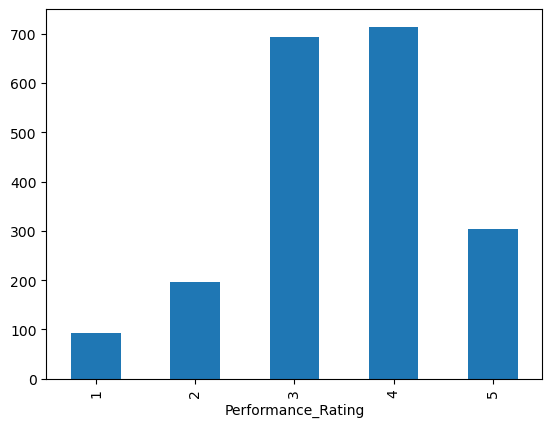

In [52]:
performance[
    'Performance_Rating'
].value_counts().sort_index().plot(
    kind='bar'
)

In [53]:
dept_performance = hr_df.groupby(
    'Department_Name'
)['Performance_Rating'].mean().sort_values(
    ascending=False
)

dept_performance

Department_Name
Marketing           3.545833
Finance             3.518367
IT                  3.512295
Administration      3.506073
Customer Support    3.434783
Operations          3.425781
Sales               3.414938
Human Resources     3.401460
Name: Performance_Rating, dtype: float64

In [54]:
performance[
    'Projects_Handled'
].describe()

count    2000.000000
mean        8.110500
std         4.333206
min         1.000000
25%         4.000000
50%         8.000000
75%        12.000000
max        15.000000
Name: Projects_Handled, dtype: float64

In [55]:
top_performers = hr_df[
    [
        'First_Name',
        'Department_Name',
        'Job_Role',
        'Performance_Rating'
    ]
].sort_values(
    by='Performance_Rating',
    ascending=False
)

top_performers.head(10)

,First_Name,Department_Name,Job_Role,Performance_Rating
1021,Hrishita,Sales,Accountant,5
1997,Mohanlal,IT,Data Analyst,5
1015,Samar,IT,HR Executive,5
32,Inaaya,Sales,HR Executive,5
1686,Shalv,IT,Operations Manager,5
1682,Fateh,IT,Marketing Manager,5
1028,Amira,Marketing,Marketing Analyst,5
1797,Drishya,Operations,Financial Analyst,5
78,Vivaan,Sales,HR Executive,5
77,Nitara,Human Resources,Accountant,5


In [56]:
performance[
    'Employee_Satisfaction_Score'
].describe()

count    2000.000000
mean        3.493400
std         0.859538
min         2.000000
25%         2.800000
50%         3.500000
75%         4.200000
max         5.000000
Name: Employee_Satisfaction_Score, dtype: float64

<Axes: >

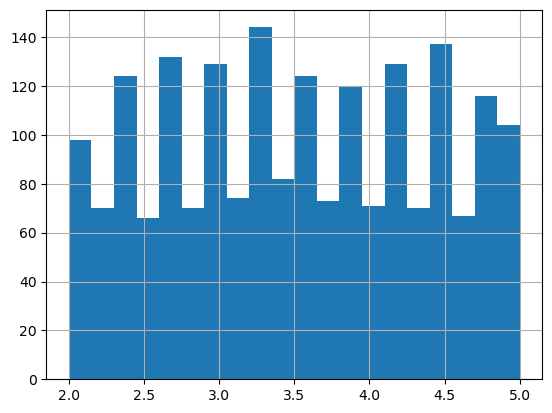

In [57]:
performance[
    'Employee_Satisfaction_Score'
].hist(
    bins=20
)

<Axes: xlabel='Training_Hours_x', ylabel='Performance_Rating'>

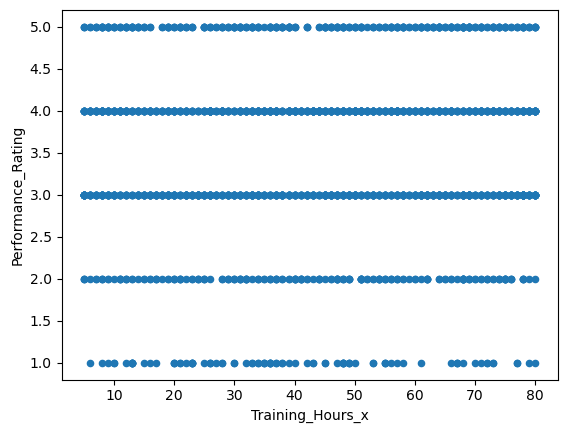

In [58]:
hr_df.plot.scatter(
    x='Training_Hours_x',
    y='Performance_Rating'
)

<Axes: xlabel='Base_Salary_INR', ylabel='Performance_Rating'>

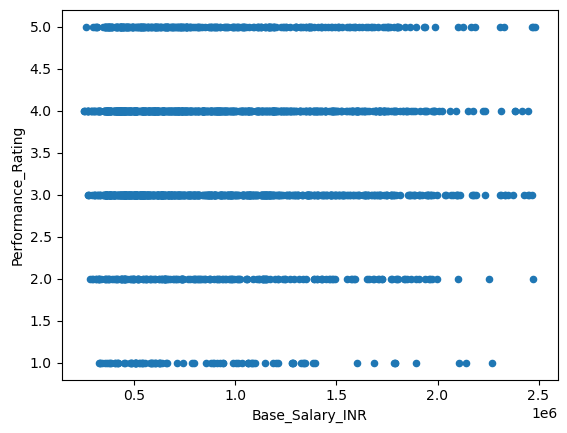

In [59]:
hr_df.plot.scatter(
    x='Base_Salary_INR',
    y='Performance_Rating'
)

## Key Insights & Recommendations

- The average employee performance rating is approximately 3.5, indicating overall stable workforce performance across the organization.

- Most employees received ratings of 3 and 4, showing that the majority of the workforce performs at an average to above-average level.

- Marketing, Finance, and IT departments demonstrate the highest average performance ratings, indicating strong departmental productivity.

- Human Resources and Sales departments show comparatively lower performance ratings, suggesting opportunities for performance improvement initiatives.

- Employees handle an average of 8 projects, reflecting a balanced workload distribution across the organization.

- Employee satisfaction scores average around 3.5 out of 5, indicating moderate employee satisfaction levels.

- The relationship between training hours and performance ratings suggests that employees with higher training exposure tend to achieve better performance outcomes.

- Technical and managerial roles receive the highest average salaries, highlighting the organization’s focus on specialized skills and leadership positions.

- IT department employees earn the highest average salaries among all departments, while Sales and Finance departments receive comparatively lower average compensation.

- Recommendation: Increase employee training and development programs to further improve performance and employee productivity.

- Recommendation: Focus on improving employee engagement and support initiatives in lower-performing departments such as Human Resources and Sales.

- Recommendation: Continue rewarding high-performing employees and investing in technical skill development to maintain organizational performance growth.

# Attendance & Work-Life Balance Analysis

In [60]:
attendance[
    'Attendance_Percentage'
].mean()

np.float64(87.649745)

<Axes: >

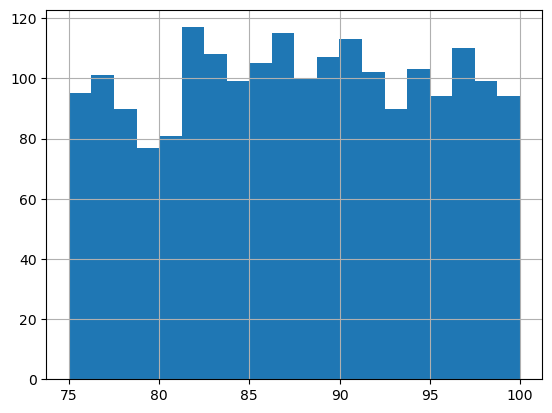

In [61]:
attendance[
    'Attendance_Percentage'
].hist(
    bins=20
)

In [62]:
dept_attendance = hr_df.groupby(
    'Department_Name'
)['Attendance_Percentage'].mean().sort_values(
    ascending=False
)

dept_attendance

Department_Name
Human Resources     88.546204
Sales               87.674896
Customer Support    87.661739
IT                  87.632090
Finance             87.526735
Administration      87.433320
Operations          87.409414
Marketing           87.211000
Name: Attendance_Percentage, dtype: float64

<Axes: xlabel='Department_Name'>

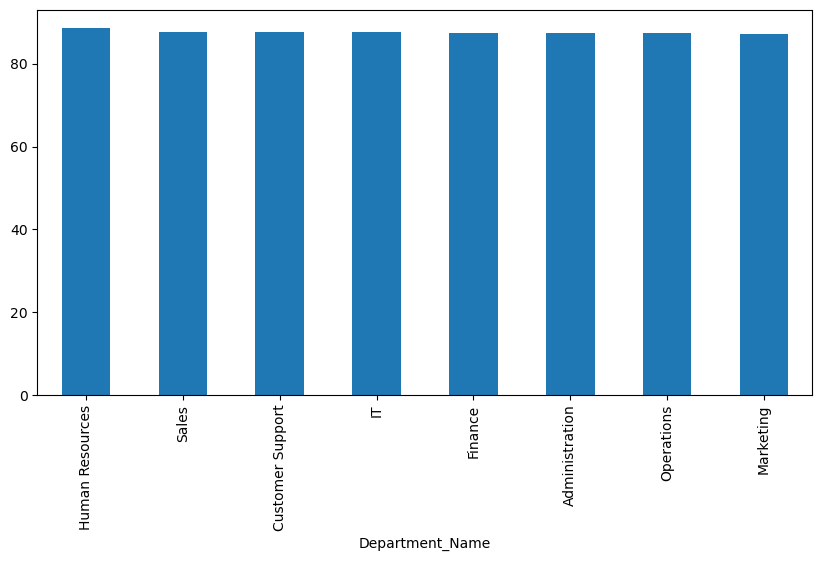

In [63]:
dept_attendance.plot(
    kind='bar',
    figsize=(10,5)
)

In [65]:
attendance[
    'Leaves_Taken'
].describe()

count    2000.000000
mean       12.537500
std         7.474793
min         0.000000
25%         6.000000
50%        13.000000
75%        19.000000
max        25.000000
Name: Leaves_Taken, dtype: float64

<Axes: >

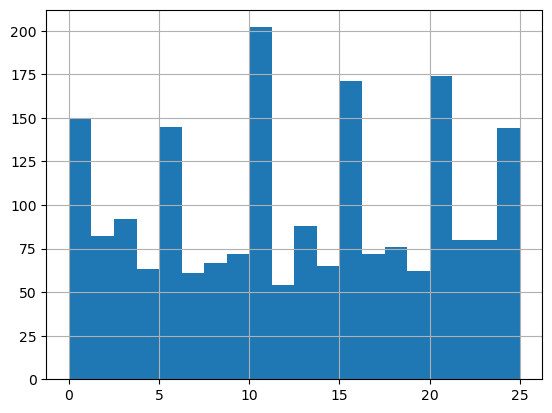

In [64]:
attendance[
    'Leaves_Taken'
].hist(
    bins=20
)

In [67]:
attendance[
    'Overtime_Hours'
].describe()

count    2000.000000
mean       20.259500
std        11.664527
min         0.000000
25%        10.000000
50%        20.000000
75%        30.000000
max        40.000000
Name: Overtime_Hours, dtype: float64

<Axes: >

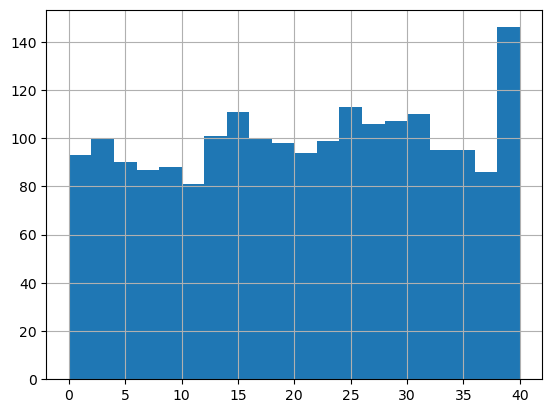

In [66]:
attendance[
    'Overtime_Hours'
].hist(
    bins=20
)

In [68]:
performance[
    'Work_Life_Balance'
].value_counts().sort_index()

Work_Life_Balance
1    394
2    378
3    416
4    421
5    391
Name: count, dtype: int64

<Axes: xlabel='Work_Life_Balance'>

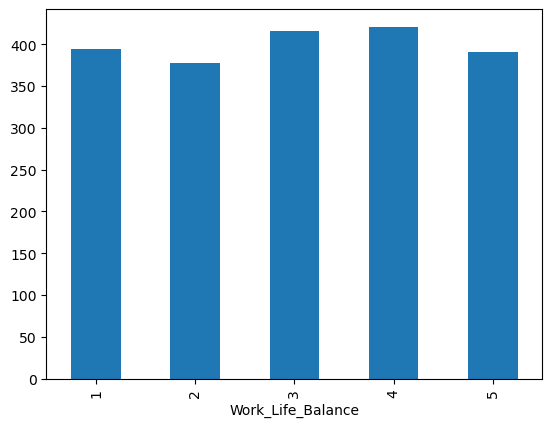

In [69]:
performance[
    'Work_Life_Balance'
].value_counts().sort_index().plot(
    kind='bar'
)

<Axes: xlabel='Overtime_Hours', ylabel='Employee_Satisfaction_Score'>

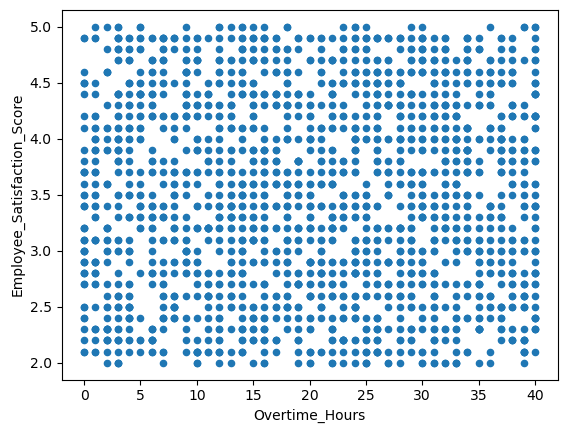

In [70]:
hr_df.plot.scatter(
    x='Overtime_Hours',
    y='Employee_Satisfaction_Score'
)

In [71]:
hr_df.groupby(
    'Work_Life_Balance'
)['Overtime_Hours'].mean()

Work_Life_Balance
1    20.147208
2    21.066138
3    20.447115
4    19.990499
5    19.682864
Name: Overtime_Hours, dtype: float64

<Axes: xlabel='Attendance_Percentage', ylabel='Performance_Rating'>

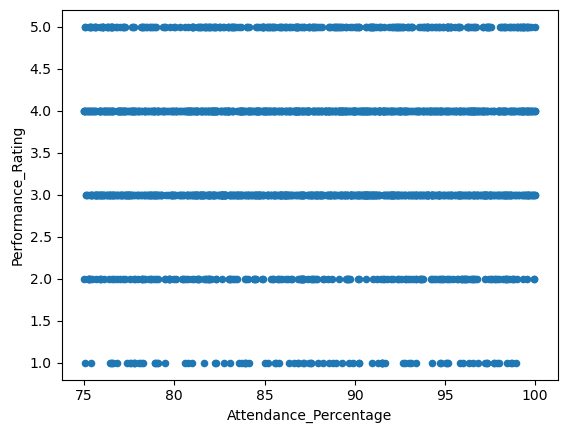

In [72]:
hr_df.plot.scatter(
    x='Attendance_Percentage',
    y='Performance_Rating'
)

## Attendance & Work-Life Balance Insights and Recommendations

- The average employee attendance percentage is approximately 87.5%, indicating strong overall employee attendance across the organization.

- Attendance levels are relatively consistent across all departments, with Human Resources showing the highest average attendance percentage.

- The relationship between attendance and performance appears moderately positive, as employees with higher attendance are more frequently associated with better performance ratings.

- Employees work an average of approximately 20 overtime hours, with overtime ranging from 0 to 40 hours.

- Work-life balance ratings are fairly distributed, with most employees reporting moderate to good work-life balance levels.

- Employees with better work-life balance tend to have slightly lower average overtime hours, suggesting that overtime may impact employee well-being.

- Employee satisfaction scores remain moderately distributed across different overtime levels, indicating that excessive overtime may not consistently improve employee satisfaction.

- Employees take an average of approximately 13 leaves, with leave counts ranging from 0 to 25.

- Recommendation: Maintain flexible work policies and balanced workload allocation to support healthy employee work-life balance.

- Recommendation: Monitor employees with consistently high overtime hours to prevent burnout and maintain long-term productivity.

- Recommendation: Continue encouraging strong attendance practices through employee engagement and supportive workplace policies.

- Recommendation: Improve employee wellness and stress-management initiatives to maintain employee satisfaction and organizational performance.

# Attrition Analysis

In [73]:
employees[
    'Attrition_Status'
].value_counts()

Attrition_Status
Active      1032
Resigned     968
Name: count, dtype: int64

<Axes: xlabel='Attrition_Status'>

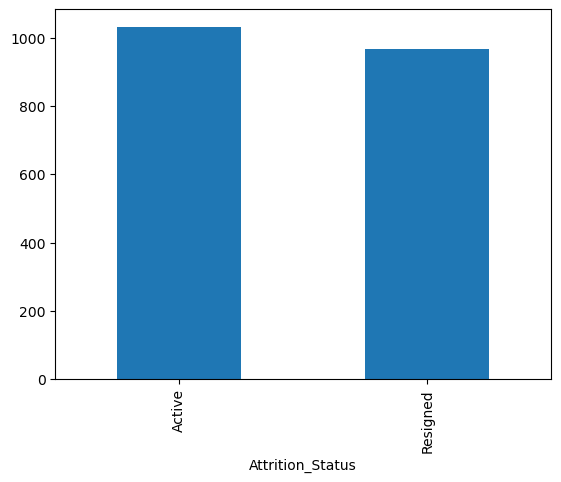

In [74]:
employees[
    'Attrition_Status'
].value_counts().plot(
    kind='bar'
)

In [75]:
attrition_rate = round(
    (
        employees[
            'Attrition_Status'
        ].value_counts(normalize=True)['Resigned']
    ) * 100,
    2
)

attrition_rate

np.float64(48.4)

In [76]:
dept_attrition = pd.crosstab(
    hr_df['Department_Name'],
    hr_df['Attrition_Status'],
    normalize='index'
) * 100

dept_attrition

Attrition_Status,Active,Resigned
Department_Name,,
Administration,49.797571,50.202429
Customer Support,47.826087,52.173913
Finance,53.061224,46.938776
Human Resources,51.094891,48.905109
IT,57.377049,42.622951
Marketing,51.250000,48.750000
Operations,52.734375,47.265625
Sales,49.792531,50.207469


<Axes: xlabel='Department_Name'>

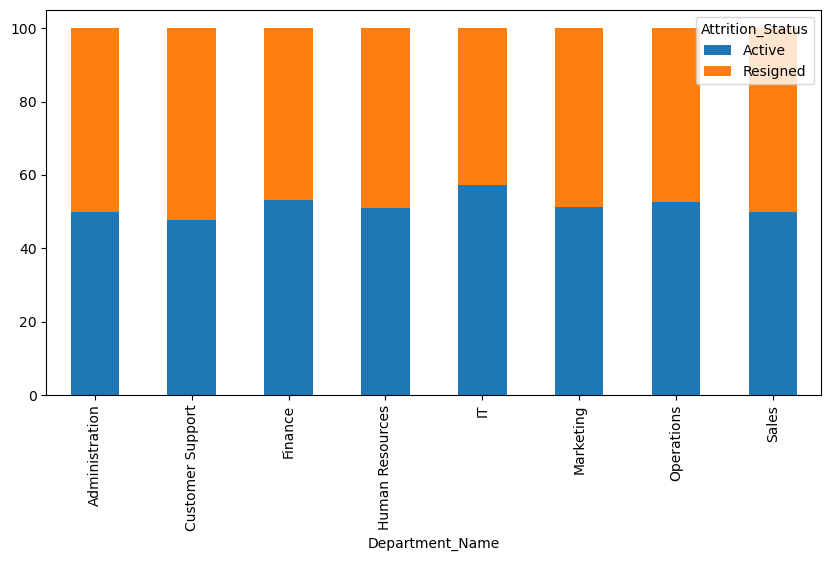

In [84]:
dept_attrition.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

In [77]:
pd.crosstab(
    hr_df['Gender'],
    hr_df['Attrition_Status']
)

Attrition_Status,Active,Resigned
Gender,,
Female,514,502
Male,518,466


In [78]:
pd.crosstab(
    hr_df['Work_Mode'],
    hr_df['Attrition_Status']
)

Attrition_Status,Active,Resigned
Work_Mode,,
Hybrid,323,333
Onsite,354,321
Remote,355,314


In [79]:
hr_df.groupby(
    'Attrition_Status'
)['Base_Salary_INR'].mean()

Attrition_Status
Active      926047.624031
Resigned    929156.865702
Name: Base_Salary_INR, dtype: float64

In [80]:
hr_df.groupby(
    'Attrition_Status'
)['Employee_Satisfaction_Score'].mean()

Attrition_Status
Active      3.495058
Resigned    3.491632
Name: Employee_Satisfaction_Score, dtype: float64

In [81]:
hr_df.groupby(
    'Attrition_Status'
)['Overtime_Hours'].mean()

Attrition_Status
Active      20.389535
Resigned    20.120868
Name: Overtime_Hours, dtype: float64

In [82]:
hr_df.groupby(
    'Attrition_Status'
)['Work_Life_Balance'].mean()

Attrition_Status
Active      3.007752
Resigned    3.029959
Name: Work_Life_Balance, dtype: float64

In [83]:
hr_df.groupby(
    'Attrition_Status'
)['Years_of_Experience'].mean()

Attrition_Status
Active      17.850775
Resigned    17.568182
Name: Years_of_Experience, dtype: float64

## Attrition Analysis Insights and Recommendations

- The organization’s attrition rate is approximately 48.4%, indicating a relatively high employee turnover level.

- Active and resigned employee counts are nearly balanced, suggesting significant workforce movement within the organization.

- Average salary, work-life balance, overtime hours, employee satisfaction, and years of experience show only minor differences between active and resigned employees.

- Employees who resigned have slightly lower employee satisfaction scores compared to active employees, indicating satisfaction may influence attrition.

- Resigned employees also show slightly lower average salaries compared to active employees.

- Work-life balance scores remain relatively similar between active and resigned employees, suggesting work-life balance alone may not be the primary driver of attrition.

- Female employees show a slightly higher resignation count compared to male employees.

- Hybrid work mode employees demonstrate slightly higher resignation counts compared to Onsite and Remote employees.

- Customer Support department has the highest resignation percentage among all departments.

- IT department has the highest active employee percentage and comparatively lower resignation levels, indicating stronger employee retention.

- Recommendation: Improve employee retention strategies in departments with higher attrition, especially Customer Support.

- Recommendation: Conduct employee feedback and exit analysis programs to better identify key reasons behind resignations.

- Recommendation: Focus on improving employee satisfaction, career growth opportunities, and compensation structures to reduce employee turnover.

- Recommendation: Strengthen employee engagement initiatives and recognition programs to improve long-term workforce retention.

# Training & Development Analysis

In [85]:
training[
    'Training_Hours'
].mean()

np.float64(20.831)

<Axes: >

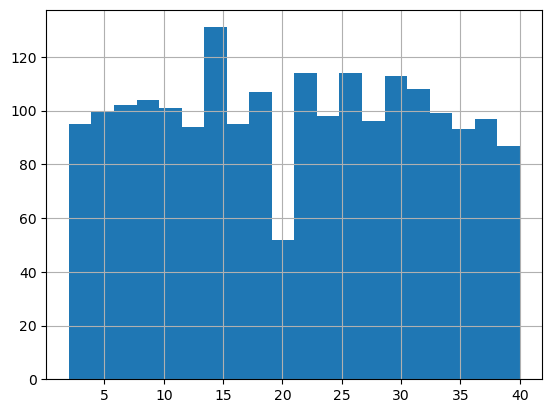

In [86]:
training[
    'Training_Hours'
].hist(
    bins=20
)

<Axes: xlabel='Training_Program'>

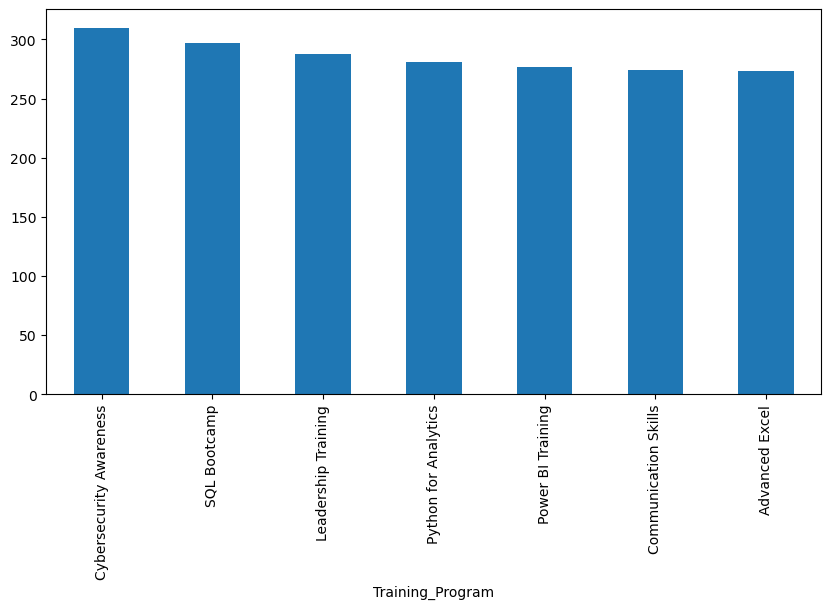

In [87]:
training[
    'Training_Program'
].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

<Axes: ylabel='count'>

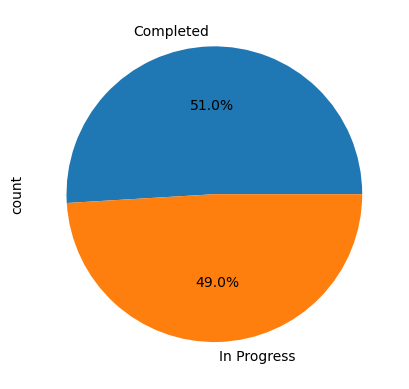

In [88]:
training[
    'Training_Status'
].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

In [90]:
dept_training = hr_df.groupby(
    'Department_Name'
)['Training_Hours_x'].mean().sort_values(
    ascending=False
)

dept_training

Department_Name
Human Resources     44.839416
Operations          44.468750
IT                  44.290984
Sales               42.995851
Marketing           42.845833
Finance             42.551020
Administration      41.862348
Customer Support    41.857708
Name: Training_Hours_x, dtype: float64

<Axes: xlabel='Department_Name'>

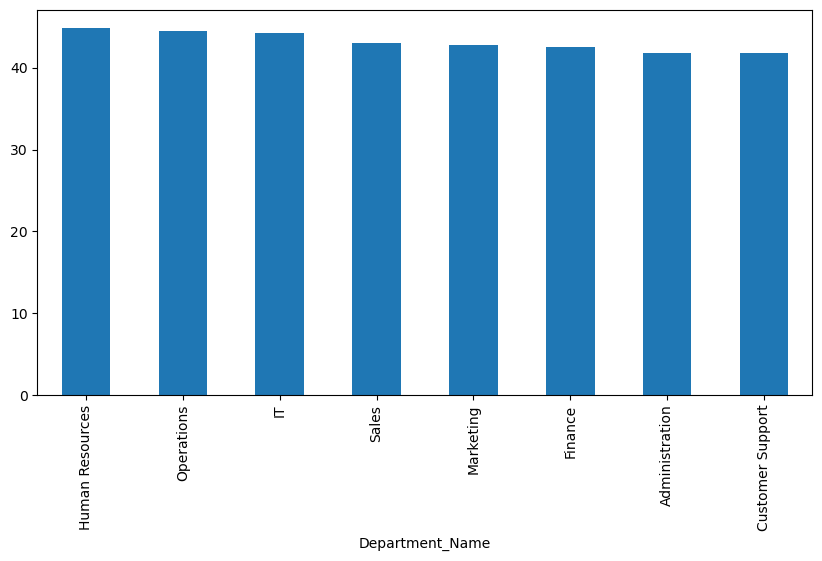

In [91]:
dept_training.plot(
    kind='bar',
    figsize=(10,5)
)

<Axes: xlabel='Training_Hours_x', ylabel='Performance_Rating'>

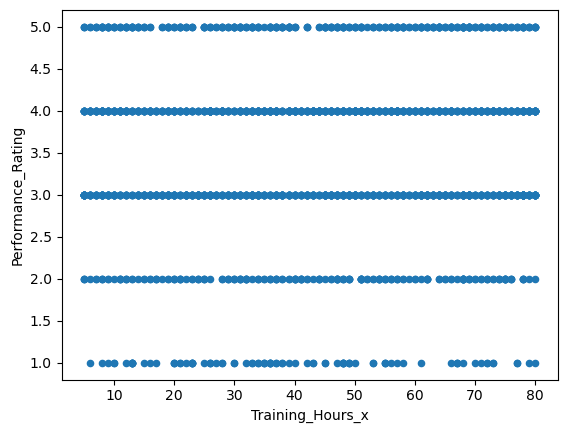

In [92]:
hr_df.plot.scatter(
    x='Training_Hours_x',
    y='Performance_Rating'
)

<Axes: xlabel='Training_Hours_x', ylabel='Employee_Satisfaction_Score'>

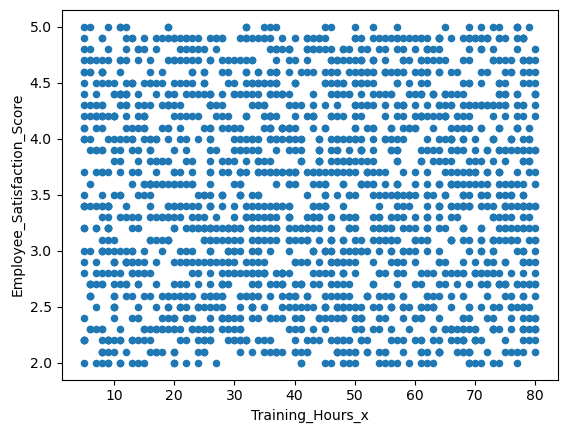

In [93]:
hr_df.plot.scatter(
    x='Training_Hours_x',
    y='Employee_Satisfaction_Score'
)

In [94]:
hr_df.groupby(
    'Training_Program'
)['Base_Salary_INR'].mean()

Training_Program
Advanced Excel             911307.776557
Communication Skills       919146.817518
Cybersecurity Awareness    869351.464516
Leadership Training        939593.798611
Power BI Training          914086.155235
Python for Analytics       978023.669039
SQL Bootcamp               964118.717172
Name: Base_Salary_INR, dtype: float64

In [95]:
hr_df[
    [
        'First_Name',
        'Department_Name',
        'Training_Hours_x'
    ]
].sort_values(
    by='Training_Hours_x',
    ascending=False
).head(10)

,First_Name,Department_Name,Training_Hours_x
22,Dhruv,IT,80
6,Eva,Operations,80
1927,Adira,Operations,80
826,Rasha,Finance,80
48,Nishith,Administration,80
589,Ishita,Operations,80
1417,Badal,Marketing,80
1890,Alia,Customer Support,80
1421,Priyansh,Marketing,80
1803,Samiha,Administration,80


## Training & Development Insights and Recommendations

- Employees complete an average of approximately 21 training hours, indicating regular participation in organizational learning programs.

- Training hours are fairly distributed across employees, with some employees completing up to 80 hours of training.

- Human Resources, Operations, and IT departments record the highest average training hours among all departments.

- Customer Support and Administration departments show comparatively lower average training hours, indicating potential opportunities for additional skill development.

- Approximately 51% of training programs are completed, while 49% remain in progress, reflecting active employee participation in ongoing learning initiatives.

- Employees enrolled in Python for Analytics and SQL Bootcamp programs receive the highest average salaries, suggesting strong market value for technical and analytical skills.

- The relationship between training hours and performance ratings appears moderately positive, as employees with higher training exposure are more frequently associated with better performance ratings.

- Recommendation: Continue investing in technical and analytical training programs to strengthen employee capabilities and organizational performance.

- Recommendation: Increase training participation in departments with comparatively lower training hours to ensure balanced employee development across the organization.

- Recommendation: Encourage employees to complete ongoing training programs to improve skill enhancement and overall productivity.

- Recommendation: Align training programs with high-demand business and technical skills to support employee career growth and long-term organizational success.

In [96]:
# Executive HR Dashboard

executive_dashboard = {

    'Total Employees':
    employees['Employee_ID'].nunique(),

    'Active Employees':
    employees[
        employees['Attrition_Status'] == 'Active'
    ]['Employee_ID'].nunique(),

    'Resigned Employees':
    employees[
        employees['Attrition_Status'] == 'Resigned'
    ]['Employee_ID'].nunique(),

    'Attrition Rate %':
    round(
        (
            employees['Attrition_Status']
            .value_counts(normalize=True)['Resigned']
        ) * 100,
        2
    ),

    'Average Salary':
    round(
        salary['Base_Salary_INR'].mean(),
        2
    ),

    'Highest Salary':
    salary['Base_Salary_INR'].max(),

    'Average Performance Rating':
    round(
        performance['Performance_Rating'].mean(),
        2
    ),

    'Average Attendance %':
    round(
        attendance['Attendance_Percentage'].mean(),
        2
    ),

    'Average Satisfaction Score':
    round(
        performance[
            'Employee_Satisfaction_Score'
        ].mean(),
        2
    ),

    'Average Training Hours':
    round(
        training['Training_Hours'].mean(),
        2
    ),

    'Average Work-Life Balance':
    round(
        performance['Work_Life_Balance'].mean(),
        2
    )

}

pd.DataFrame(
    executive_dashboard.items(),
    columns=['KPI', 'Value']
)

,KPI,Value
0,Total Employees,2000.00
1,Active Employees,1032.00
2,Resigned Employees,968.00
3,Attrition Rate %,48.40
4,Average Salary,927552.50
5,Highest Salary,2482541.00
6,Average Performance Rating,3.47
7,Average Attendance %,87.65
8,Average Satisfaction Score,3.49
9,Average Training Hours,20.83
